# k-평균 군집분석을 이용한 통신 가입자 세그먼트화


## 요약

한 통신사가 후불 가입자 기반을 행동 세그먼트로 그룹화하여 리텐션 오퍼를 타기팅하고 데이터 요금제를 적절히 조정하려 한다. 이 노트북은 합성 가입자 사용 데이터셋을 생성한 뒤, Base SAS로 완전한 k-평균 세그먼트화 파이프라인을 실행한다: **PROC STDIZE**로 사용량 변수를 표준화하고, **PROC FASTCLUS**로 후보 k에 걸쳐 pseudo-F 통계량을 비교하여 군집 수를 선택하고, 모든 가입자를 스코어링하는 FREQ 가중 최종 모델을 적합한 다음, 학습된 중심점을 내보내 다음 달 스냅샷을 재군집화 없이 스코어링할 수 있도록 한다. 그 결과물은 원시 사용 텔레메트리를 리텐션 플레이북에 매핑하는 재사용 가능한 세그먼트화이다.


## 데이터 출처

**합성 데이터셋: `WORK.SUBSCRIBERS`** (후불 모바일 가입자 100명, `call streaminit(20260531)`로 인라인 생성)

| 변수 | 유형 | 역할 | 설명 |
|----------|------|------|-------------|
| `cust_id` | 문자 | ID | 가입자 식별자 (예: `SUB000123`) |
| `tenure_months` | 숫자 | 구간 입력 | 회선이 활성화된 개월 수 (1-72) |
| `data_gb` | 숫자 | 구간 입력 | 월평균 모바일 데이터 사용량(GB) |
| `voice_min` | 숫자 | 구간 입력 | 월평균 음성 통화 사용량(분) |
| `intl_min` | 숫자 | 구간 입력 | 월평균 국제전화 사용량(분) |
| `support_calls` | 숫자 | 구간 입력 | 최근 90일간 고객센터 문의 건수 |
| `monthly_charge` | 숫자 | 구간 입력 | 현재 월 청구액(달러) |
| `plan_tier` | 문자 | 프로파일링 | 요금제: `베이직`, `플러스`, `무제한` |
| `n_lines` | 숫자 | FREQ 가중치 | 계정의 회선 수 |

생성기에는 세 가지 잠재 행동 프로파일 - *경량/가치 지향*, *헤비 데이터/스트리밍*, *고접촉/이탈 위험* - 이 내재되어 있어, 군집분석이 실제로 발견할 구조를 갖는다. 구간형 변수들이 k-평균 모델에 입력되며, `plan_tier`는 사후 프로파일링을 위해 남겨두고, `n_lines`는 계정별 회선 수로 가중치를 부여한다. 외부 파일이나 네트워크 접근은 사용하지 않는다.


## 다섯 단계로 진행하는 행동 세그먼트화

이동통신사는 수백만 개의 후불 회선을 보유하고 있으며, 획일적인 리텐션 전략은 어차피 남아 있을 고객에게 마진을 낭비하면서 곧 이탈할 고객은 놓친다. **행동 세그먼트화**는 원시 사용 텔레메트리를 실행 가능한 소수의 고객 유형으로 바꾼다: 가격에 민감한 *경량/가치 지향* 사용자, 업셀링 대상이 되는 *헤비 데이터 스트리머*, 선제적 케어가 필요한 *고접촉/이탈 위험* 계정.

이 노트북은 SAS의 k-평균(비중첩 군집) 프로시저인 `PROC FASTCLUS`로 세그먼트화를 구축한다. 다음을 수행한다:

1. 합성이지만 현실적인 가입자 사용 데이터셋을 생성한다.
2. **PROC STDIZE**로 사용량 변수를 공통 척도에 맞춘다.
3. 후보 k에 걸쳐 pseudo-F 통계량을 비교하여 **군집 수를 선택**한다.
4. 모든 가입자를 **스코어링**하고 세그먼트를 프로파일링하는 FREQ 가중 최종 모델을 적합한다.
5. 모델을 다음 달 스냅샷에 재적용할 수 있도록 **학습된 중심점을 내보낸다**.


## 1단계 - 합성 가입자 기반 생성

후불 가입자 100명을 시뮬레이션한다. 각 가입자는 서로 다른 사용 패턴을 가진 세 가지 잠재 프로파일 중 하나에서 추출되므로, 회복할 실제 군집 구조가 존재한다. 재현성을 위해 `call streaminit`으로 스트림을 고정하고, `max`/`min`/`round`로 시뮬레이션 값을 타당한 범위로 제한한다.

명목형 `plan_tier`는 잠재 프로파일과 상관관계를 가진다(스트리머는 *무제한* 쪽으로, 가치 지향 사용자는 *베이직* 쪽으로 치우친다). `n_lines`는 이후 FREQ 가중치로 사용되어, 다회선 가족 계정이 비례하여 반영되도록 한다.


In [1]:
데이터 subscribers;
    호출 streaminit(20260531);
    길이 cust_id $9 plan_tier $9;
    반복 i = 1 까지 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* Three latent behavioral profiles, ~unequal prevalence */
        u = rand('uniform');
        만약 u < 0.45 이면 profile = 1;        /* light / value        */
        아니면 만약 u < 0.80 이면 profile = 2;   /* heavy-data streamer   */
        아니면 profile = 3;                    /* high-touch / at-risk  */

        만약 profile = 1 이면 반복;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        종료;
        아니면 만약 profile = 2 이면 반복;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        종료;
        아니면 반복;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        종료;

        /* Plan tier correlated with profile */
        p = rand('uniform');
        만약 profile = 1 이면
            plan_tier = ifc(p < 0.70, '베이직', ifc(p < 0.95, '플러스', '무제한'));
        아니면 만약 profile = 2 이면
            plan_tier = ifc(p < 0.65, '무제한', ifc(p < 0.90, '플러스', '베이직'));
        아니면
            plan_tier = ifc(p < 0.45, '플러스', ifc(p < 0.80, '무제한', '베이직'));

        /* Lines on the account: most are single-line */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Round monetary / usage values to realistic precision */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        출력;
    종료;
    제거 i u p profile;
실행;

처리 인쇄 데이터=subscribers(obs=10) noobs 라벨;
    라벨 cust_id='고객 ID' tenure_months='가입 기간(개월)' data_gb='평균 데이터 사용량(GB)'
          voice_min='평균 음성 사용량(분)' intl_min='평균 국제전화 사용량(분)'
          support_calls='고객센터 문의 건수' monthly_charge='월 청구액(달러)'
          plan_tier='요금제' n_lines='회선 수';
    제목 '합성 가입자 사용 기록 샘플';
실행;


                                                    합성 가입자 사용 기록 샘플                                                     

    고객 ID        요금제              가입 기간(개월)                  평균 데이터 사용량(GB)                  평균 음성 사용량(분)                      평균 국제전화 사용량(분)                  고객센터 문의 건수              월 청구액(달러)        회선 수
SUB000001  베이직                           15                             9.7                           114                                   5                          11                  57.07           2
SUB000002  베이직                           39                             0.6                           214                                   2                           1                  35.88           3
SUB000003  무제한                           45                            23.9                           325                                   6                           1                 103.94           2
SUB000004  베이직                           41               


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## 2단계 - 변수들을 공통 척도로 맞추기

k-평균은 유클리드 거리를 사용하므로, 음성 통화 분처럼 값의 크기가 큰 변수는 고객센터 문의 건수처럼 값의 크기가 작은 변수를 원시값 그대로 군집화할 경우 압도해버린다. 표준적인 해법은 먼저 모든 구간형 변수를 평균 0, 표준편차 1로 표준화하는 것이다. `METHOD=STD`를 지정한 **PROC STDIZE**가 정확히 그 작업을 수행하여, z-점수화된 사본을 `WORK.SUBS_STD`에 기록한다. `cust_id`, `plan_tier`, `n_lines`는 그대로 유지하여 이후 가중치 부여와 프로파일링에 사용할 수 있도록 한다.


In [2]:
처리 stdize 데이터=subscribers out=subs_std METHOD=std;
    변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
실행;

처리 평균 데이터=subs_std mean std maxdec=3;
    변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    라벨 tenure_months='가입 기간(개월)' data_gb='평균 데이터 사용량(GB)'
          voice_min='평균 음성 사용량(분)' intl_min='평균 국제전화 사용량(분)'
          support_calls='고객센터 문의 건수' monthly_charge='월 청구액(달러)';
    제목 '표준화된 변수: 평균 ~ 0, 표준편차 ~ 1';
실행;


                                                    합성 가입자 사용 기록 샘플                                                     

                                               표준화된 변수: 평균 ~ 0, 표준편차 ~ 1                                                

                                                  The MEANS Procedure

 Variable        Label                                        Mean     Std Dev
 -----------------------------------------------------------------------------
 tenure_months   가입 기간(개월)                                   0.000       1.000
 data_gb         평균 데이터 사용량(GB)                             -0.000       1.000
 voice_min       평균 음성 사용량(분)                               -0.000       1.000
 intl_min        평균 국제전화 사용량(분)                              0.000       1.000
 support_calls   고객센터 문의 건수                                 -0.000       1.000
 monthly_charge  월 청구액(달러)                                   0.000       1.000
 ----------------------------------------------------


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3단계 - 몇 개의 세그먼트가 적절한가? 후보 k에 걸친 pseudo-F 비교

군집 수를 추측하는 대신, 각 후보 k에서 FASTCLUS를 적합하고 그것이 보고하는 모델 적합도 통계량을 읽는다. **pseudo-F 통계량**(군집 간 분산 대 군집 내 분산의 비율)과 **전체 R-제곱** 모두 분리도가 높을수록 커진다. 좋은 k는 pseudo-F가 높으면서 군집을 하나 더 추가해도 얻는 것이 점점 줄어드는 지점이다. 짧은 매크로 루프가 `MAXITER=50`과 `CONVERGE=0`(안정될 때까지 반복)으로 k = 2, 3, 4를 실행한다. 아래 세 개의 리스팅에서 `Pseudo F Statistic`과 `Overall R-Squared` 값을 비교해 보라: 내재된 구조는 세 가지 잠재 프로파일이며, k = 3이 가장 강력하고 균형 잡힌 해를 제공한다.


In [3]:
%macro pick_k;
    %반복 k = 2 %까지 4;
        처리 FASTCLUS 데이터=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            제목 "후보 군집 수: k = &k";
        실행;
    %종료;
%mend pick_k;
%pick_k;


                                               표준화된 변수: 평균 ~ 0, 표준편차 ~ 1                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## 4단계 - 최종 세그먼트화를 적합하고 모든 가입자를 스코어링

k = 3을 선택했으니, 이제 운영 모델을 적합한다. 이번 실행은 운영용 세그먼트화에 완전히 부합하는 형태이다:

- `FREQ` 문은 각 계정을 `n_lines`로 가중하므로, 회선이 네 개인 가족 계정은 중심점을 계산할 때 회선이 하나인 계정보다 네 배 더 기여한다.
- `OUT=SCORED`는 모든 가입자에 대해 할당된 `CLUSTER`와 해당 군집 중심점까지의 `DISTANCE`를 함께 기록한다. `ID` 문은 `cust_id`를 이 스코어링 테이블에 실어 나른다.
- `MEAN=SEG_MEANS`는 (표준화 척도 기준) 군집별 중심점을 담는다.
- `OUTSEED=SEG_SEEDS`는 FASTCLUS가 다시 읽을 수 있는 시드 형식으로 최종 중심점을 저장한다 - 이것이 6단계에서 재적용할 내보낸 모델이다.

모델 적합도 통계량은 이미 3단계 스윕에서 확인했으므로, 여기서는 `SHORT` 옵션을 추가하여 스코어링 결과를 만들어내는 군집 크기와 중심점에 리스팅을 집중시킨다.


In [4]:
처리 FASTCLUS 데이터=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    빈도 n_lines;
    id cust_id;
    제목 '최종 세그먼트: k = 3, 회선 수로 가중';
실행;

처리 인쇄 데이터=seg_means noobs 라벨;
    라벨 tenure_months='가입 기간(개월)' data_gb='평균 데이터 사용량(GB)'
          voice_min='평균 음성 사용량(분)' intl_min='평균 국제전화 사용량(분)'
          support_calls='고객센터 문의 건수' monthly_charge='월 청구액(달러)';
    제목 '세그먼트 중심점 (표준화 척도)';
실행;


                                               표준화된 변수: 평균 ~ 0, 표준편차 ~ 1                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## 5단계 - 세그먼트를 비즈니스 단위로 프로파일링

스코어링 테이블은 각 가입자의 `CLUSTER` 할당을 담고 있지만, 표준화 척도에서는 중심점을 읽기가 어렵다. 군집 번호를 비즈니스 페르소나로 바꾸기 위해 할당 결과를 원본 `subscribers` 테이블에 다시 조인하고 실제 단위 - 기가바이트, 분, 달러 - 로 프로파일링한다. PROC MEANS는 세그먼트별로 구간형 변수를 요약하고, PROC FREQ는 남겨두었던 `plan_tier`를 세그먼트와 교차분석하여 각 페르소나의 요금제 구성을 보여준다.


                                              세그먼트 프로파일: 군집별 평균 사용량 (원 단위)                                              

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months 가입 기간(개월)

                                            N
                          세그먼트            Obs      Mean      Std Dev      Minimum      Maximum
                          --------------------------------------------------------------------
                          1                51      33.2         14.7          1.0         61.0
                          2                31      40.5         14.0         17.0         67.0
                          3                18      12.7          7.1          1.0         30.0
                          --------------------------------------------------------------------

                              Analysis Variable : data_gb 평균 데이터 사용량(GB)

                                       


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


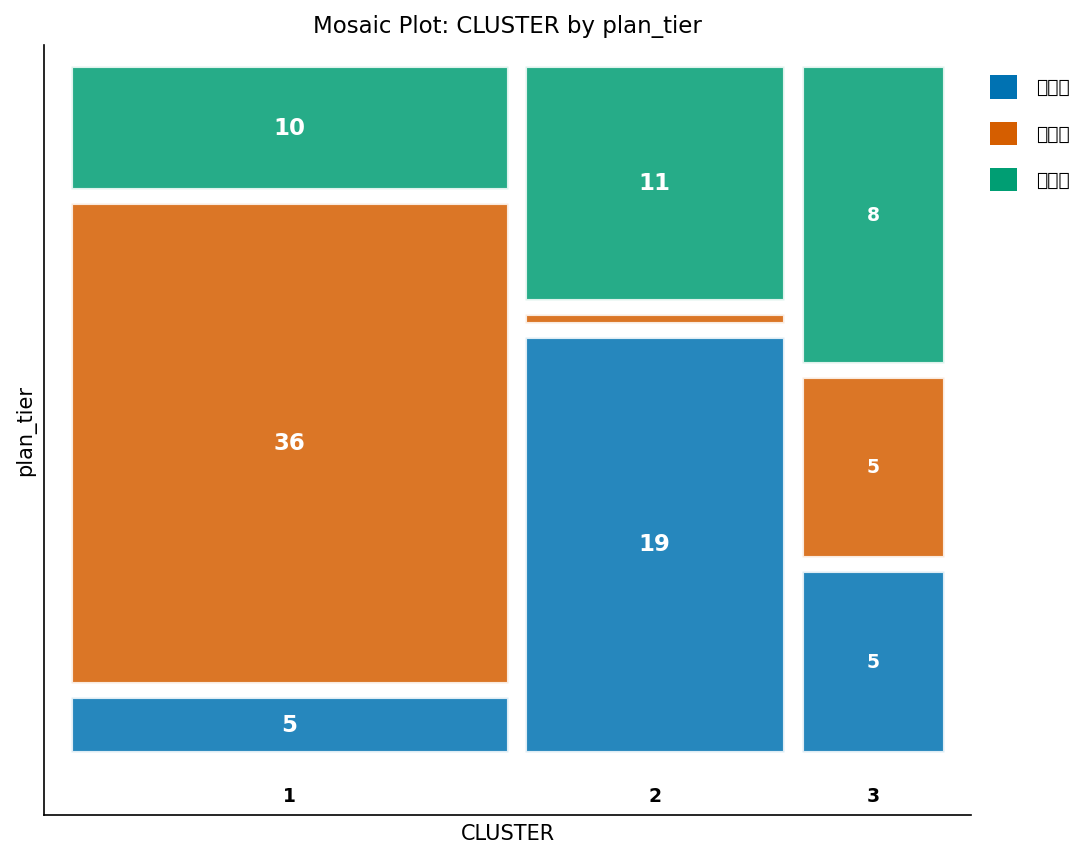

In [5]:
처리 정렬 데이터=scored out=scored_keys(유지=cust_id CLUSTER);
    기준 cust_id;
실행;

처리 정렬 데이터=subscribers out=subs_sorted;
    기준 cust_id;
실행;

데이터 profile;
    결합 subs_sorted(IN=a) scored_keys(IN=b);
    기준 cust_id;
    만약 a 그리고 b;
실행;

처리 평균 데이터=profile mean std MIN MAX maxdec=1;
    분류 CLUSTER;
    변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    라벨 CLUSTER='세그먼트' tenure_months='가입 기간(개월)' data_gb='평균 데이터 사용량(GB)'
          voice_min='평균 음성 사용량(분)' intl_min='평균 국제전화 사용량(분)'
          support_calls='고객센터 문의 건수' monthly_charge='월 청구액(달러)';
    제목 '세그먼트 프로파일: 군집별 평균 사용량 (원 단위)';
실행;

처리 빈도 데이터=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    라벨 CLUSTER='세그먼트' plan_tier='요금제';
    제목 '세그먼트별 요금제 구성';
실행;


## 6단계 - 다음 달 스냅샷에 모델 재적용

세그먼트화는 전체 작업을 다시 실행하지 않고도 재적용할 수 있어야 유용하다. 4단계에서 `SEG_SEEDS`에 저장한 중심점은 이식 가능한 모델이다. 이를 `SEED=SEG_SEEDS`와 `MAXITER=0`으로 다시 입력하면 FASTCLUS는 중심점을 이동시키지 않고 각 관측치를 가장 가까운 저장된 중심점에 *할당*만 한다 - 순수한 스코어링이지 재적합이 아니다. 여기서는 동일한 표준화 스냅샷을 재스코어링하여 내보낸 모델이 원래 할당을 재현하는지 확인한다. 실무에서는 `DATA=`가 다음 달의 표준화된 스냅샷을 가리키도록 하면 된다.


                                                      세그먼트별 요금제 구성                                                      


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


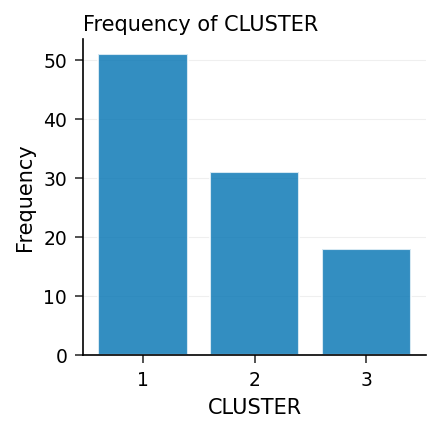

In [6]:
처리 FASTCLUS 데이터=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    변수 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    제목 '내보낸 중심점으로 새 스냅샷 스코어링';
실행;

처리 빈도 데이터=rescored;
    TABLES CLUSTER / nocum;
    라벨 CLUSTER='세그먼트';
    제목 '내보낸 모델로 재점수화된 가입자';
실행;


## 결과 해석

FASTCLUS는 데이터에 내재된 세 가지 행동 세그먼트를 회복했고, 프로파일링 테이블은 이를 리텐션 플레이북으로 옮겨준다. 위의 *세그먼트 프로파일* 테이블에서 세그먼트 번호를 확인하라 - 군집 라벨은 임의적이므로, 각 페르소나는 사용 패턴으로 식별해야 한다:

- **경량/가치 지향 사용자** - 낮은 데이터 사용량, 적당한 청구액, 긴 가입 기간, 매우 적은 고객센터 문의, 대부분 *베이직* 요금제. 이 고객들은 안정적이고 가격에 민감하다. 올바른 대응은 할인이 아니라 *마진 보호*이다. 적절한 크기의 요금제 추천은 사은품 없이도 요금 충격을 막아준다.
- **헤비 데이터 스트리머** - 높은 데이터 사용량, 높은 음성 및 국제전화 사용량, 프리미엄 청구액, 대부분 *무제한* 요금제. 충성도가 높고 고가치 고객이다. 대응은 *업셀링과 기기 업그레이드*, 그리고 경쟁사 프로모션에 흔들리지 않도록 하는 선제적 네트워크 품질 메시징이다.
- **고접촉/이탈 위험** - 짧은 가입 기간, 높은 고객센터 문의량, 중간 수준의 지출. 잦은 케어 접촉과 짧은 가입 기간은 전형적인 이탈 전조 신호이다. 이 세그먼트는 *선제적 리텐션 오퍼*와 서비스 복구 후속 조치가 필요하다.

이번 분석을 신뢰할 수 있게 만든 핵심 프로시저 선택: **PROC STDIZE**는 값의 크기가 큰 음성 통화 분이 고객센터 문의 신호를 압도하지 않도록 했고, pseudo-F 스윕은 군집 수를 추측이 아니라 근거로 정당화했으며, `FREQ` 가중치는 다회선 가족 계정이 그 비중만큼 반영되도록 했고, `OUTSEED=`/`SEED=` 왕복은 중심점을 내보내 마케팅팀이 `MAXITER=0` FASTCLUS 호출 한 번으로 매달 스냅샷을 재세그먼트화할 수 있게 했다 - 재군집화가 필요 없다.
